In [5]:
!pip install yfinance --quiet
import yfinance as yf
import pandas as pd
import numpy as np
import sqlite3
import os

os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("db", exist_ok=True)

In [6]:
TICKERS = ["RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "INFY.NS", "HINDUNILVR.NS", "BHARTIARTL.NS", "^NSEI"]
START = "2021-01-01"
END = "2026-07-01"

raw_data = {}

for ticker in TICKERS:
    print(f"Extracting {ticker}...")
    df = yf.download(ticker, start=START, end=END, progress=False)
    df = df.reset_index()
    df["Ticker"] = ticker
    filepath = f"data/raw/{ticker.replace('^','IDX_')}.csv"
    df.to_csv(filepath, index=False)
    raw_data[ticker] = df
    print(f"  Saved {len(df)} rows -> {filepath}")

Extracting RELIANCE.NS...


/tmp/ipykernel_1503/972332801.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START, end=END, progress=False)


  Saved 1359 rows -> data/raw/RELIANCE.NS.csv
Extracting TCS.NS...


/tmp/ipykernel_1503/972332801.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START, end=END, progress=False)


  Saved 1359 rows -> data/raw/TCS.NS.csv
Extracting HDFCBANK.NS...


...

  Saved 1359 rows -> data/raw/HINDUNILVR.NS.csv
Extracting BHARTIARTL.NS...


/tmp/ipykernel_1503/972332801.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START, end=END, progress=False)


  Saved 1359 rows -> data/raw/BHARTIARTL.NS.csv
Extracting ^NSEI...


/tmp/ipykernel_1503/972332801.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START, end=END, progress=False)


  Saved 1355 rows -> data/raw/IDX_NSEI.csv


In [4]:
def extract_ticker_data(ticker: str, start: str, end: str) -> pd.DataFrame:
    """
    Fetches daily OHLCV data for a single ticker between start and end dates.

    Parameters
    ----------
    ticker : str        e.g. "RELIANCE.NS", "AAPL", "^NSEI"
    start  : str        "YYYY-MM-DD"
    end    : str        "YYYY-MM-DD"

    Returns
    -------
    pd.DataFrame with columns: Date, Open, High, Low, Close, Volume
    """
    df = yf.download(ticker, start=start, end=end, progress=False)
    df = df.reset_index()
    df["Ticker"] = ticker
    return df

In [7]:
raw_data = {}
for ticker in TICKERS:
    print(f"Extracting {ticker}...")
    df = yf.download(ticker, start=START, end=END, progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df.reset_index()
    df["Ticker"] = ticker
    filepath = f"data/raw/{ticker.replace('^','IDX_')}.csv"
    df.to_csv(filepath, index=False)
    raw_data[ticker] = df
    print(f"  Saved {len(df)} rows -> {filepath}")

Extracting RELIANCE.NS...
  Saved 1359 rows -> data/raw/RELIANCE.NS.csv
Extracting TCS.NS...
  Saved 1359 rows -> data/raw/TCS.NS.csv
Extracting HDFCBANK.NS...
  Saved 1359 rows -> data/raw/HDFCBANK.NS.csv
Extracting INFY.NS...


/tmp/ipykernel_1503/3364258825.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START, end=END, progress=False)
/tmp/ipykernel_1503/3364258825.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START, end=END, progress=False)
/tmp/ipykernel_1503/3364258825.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START, end=END, progress=False)
/tmp/ipykernel_1503/3364258825.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START, end=END, progress=False)


  Saved 1359 rows -> data/raw/INFY.NS.csv
Extracting HINDUNILVR.NS...
  Saved 1359 rows -> data/raw/HINDUNILVR.NS.csv
Extracting BHARTIARTL.NS...
  Saved 1359 rows -> data/raw/BHARTIARTL.NS.csv
Extracting ^NSEI...
  Saved 1355 rows -> data/raw/IDX_NSEI.csv


/tmp/ipykernel_1503/3364258825.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START, end=END, progress=False)
/tmp/ipykernel_1503/3364258825.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START, end=END, progress=False)
/tmp/ipykernel_1503/3364258825.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START, end=END, progress=False)


In [8]:
def clean_data(df):
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").drop_duplicates(subset="Date")
    required_cols = ["Open", "High", "Low", "Close", "Volume"]
    df = df.dropna(subset=required_cols)
    df = df[df["High"] >= df["Low"]]
    return df.reset_index(drop=True)

def compute_returns(df):
    df = df.copy()
    df["Daily_Return"] = df["Close"].pct_change()
    df["Log_Return"] = np.log(df["Close"] / df["Close"].shift(1))
    return df

def compute_rolling_volatility(df, windows=(20, 60)):
    df = df.copy()
    for w in windows:
        df[f"Volatility_{w}d"] = df["Daily_Return"].rolling(window=w).std() * np.sqrt(252)
    return df

def compute_moving_averages(df, windows=(20, 50, 200)):
    df = df.copy()
    for w in windows:
        df[f"SMA_{w}"] = df["Close"].rolling(window=w).mean()
    return df

def compute_cumulative_returns(df):
    df = df.copy()
    df["Cumulative_Return"] = (1 + df["Daily_Return"].fillna(0)).cumprod()
    return df

processed_data = {}

for ticker, df in raw_data.items():
    print(f"Transforming {ticker}...")
    df = clean_data(df)
    df = compute_returns(df)
    df = compute_rolling_volatility(df)
    df = compute_moving_averages(df)
    df = compute_cumulative_returns(df)
    processed_data[ticker] = df
    filepath = f"data/processed/{ticker.replace('^','IDX_')}.csv"
    df.to_csv(filepath, index=False)
    print(f"  Saved -> {filepath}")

# quick sanity check
processed_data["RELIANCE.NS"][["Date","Close","Daily_Return","Volatility_20d","SMA_20","SMA_50","Cumulative_Return"]].tail(10)

Transforming RELIANCE.NS...
  Saved -> data/processed/RELIANCE.NS.csv
Transforming TCS.NS...
  Saved -> data/processed/TCS.NS.csv
Transforming HDFCBANK.NS...
  Saved -> data/processed/HDFCBANK.NS.csv
Transforming INFY.NS...
  Saved -> data/processed/INFY.NS.csv
Transforming HINDUNILVR.NS...
  Saved -> data/processed/HINDUNILVR.NS.csv
Transforming BHARTIARTL.NS...
  Saved -> data/processed/BHARTIARTL.NS.csv
Transforming ^NSEI...
  Saved -> data/processed/IDX_NSEI.csv


Price,Date,Close,Daily_Return,Volatility_20d,SMA_20,SMA_50,Cumulative_Return
1349,2026-06-17,1332.699951,0.002935,0.175415,1312.012042,1346.019858,1.485652
1350,2026-06-18,1328.099976,-0.003452,0.173958,1311.247607,1345.749917,1.480524
1351,2026-06-19,1309.500000,-0.014005,0.179557,1309.309302,1345.462339,1.459790
1352,2026-06-22,1326.500000,0.012982,0.182965,1307.598871,1345.112620,1.478741
1353,2026-06-23,1309.500000,-0.012816,0.186187,1305.570972,1345.121670,1.459790
1354,2026-06-24,1313.599976,0.003131,0.186556,1304.036743,1344.635388,1.464360
1355,2026-06-25,1318.099976,0.003426,0.187216,1302.727515,1344.255032,1.469377
1356,2026-06-26,1318.099976,0.000000,0.170360,1302.876544,1343.442673,1.469377
1357,2026-06-29,1301.000000,-0.012973,0.176638,1302.230298,1342.322158,1.450314
1358,2026-06-30,1293.900024,-0.005457,0.177079,1301.497809,1341.258723,1.442399


In [9]:
conn = sqlite3.connect("db/market_data.db")

# Combine all processed dataframes into one table (long format, keyed by Ticker + Date)
all_dfs = []
for ticker, df in processed_data.items():
    df_copy = df.copy()
    df_copy["Ticker"] = ticker  # ensure consistent ticker label
    all_dfs.append(df_copy)

combined_df = pd.concat(all_dfs, ignore_index=True)

# Load into a single table called 'market_data'
combined_df.to_sql("market_data", conn, if_exists="replace", index=False)

# Create an index on (Ticker, Date) for fast lookups — standard relational DB practice
conn.execute("CREATE INDEX IF NOT EXISTS idx_ticker_date ON market_data(Ticker, Date)")
conn.commit()

print(f"Loaded {len(combined_df)} total rows into db/market_data.db")

# Sanity check: query it back
check = pd.read_sql("SELECT Ticker, COUNT(*) as rows, MIN(Date) as first_date, MAX(Date) as last_date FROM market_data GROUP BY Ticker", conn)
check


Loaded 9509 total rows into db/market_data.db


,Ticker,rows,first_date,last_date
0,BHARTIARTL.NS,1359,2021-01-01 00:00:00,2026-06-30 00:00:00
1,HDFCBANK.NS,1359,2021-01-01 00:00:00,2026-06-30 00:00:00
2,HINDUNILVR.NS,1359,2021-01-01 00:00:00,2026-06-30 00:00:00
3,INFY.NS,1359,2021-01-01 00:00:00,2026-06-30 00:00:00
4,RELIANCE.NS,1359,2021-01-01 00:00:00,2026-06-30 00:00:00
5,TCS.NS,1359,2021-01-01 00:00:00,2026-06-30 00:00:00
6,^NSEI,1355,2021-01-01 00:00:00,2026-06-30 00:00:00


In [10]:
from scipy import stats

# Pull data back from the database (proving the DB is actually useful, not just storage)
query = "SELECT Date, Ticker, Close, Daily_Return FROM market_data"
df_all = pd.read_sql(query, conn, parse_dates=["Date"])

# Pivot into wide format: one column per ticker's daily return
returns_wide = df_all.pivot(index="Date", columns="Ticker", values="Daily_Return")

# 1. CORRELATION MATRIX across all stocks + index
corr_matrix = returns_wide.corr()
print("=== Correlation Matrix (Daily Returns) ===")
display(corr_matrix.round(2))

# 2. BETA via linear regression: each stock's return regressed against index (^NSEI) return
benchmark = "^NSEI"
beta_results = []

for ticker in returns_wide.columns:
    if ticker == benchmark:
        continue
    paired = returns_wide[[ticker, benchmark]].dropna()
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        paired[benchmark], paired[ticker]
    )
    beta_results.append({
        "Ticker": ticker,
        "Beta": round(slope, 3),
        "Alpha_daily": round(intercept, 5),
        "R_squared": round(r_value**2, 3),
        "P_value": round(p_value, 5)
    })

beta_df = pd.DataFrame(beta_results).sort_values("Beta", ascending=False)
print("\n=== Beta vs NSEI (Linear Regression) ===")
display(beta_df)

# 3. DISPERSION comparison: average annualized volatility per ticker
vol_query = """
SELECT Ticker, AVG(Volatility_20d) as avg_vol_20d, AVG(Volatility_60d) as avg_vol_60d
FROM market_data
WHERE Volatility_20d IS NOT NULL
GROUP BY Ticker
ORDER BY avg_vol_20d DESC
"""
vol_summary = pd.read_sql(vol_query, conn)
print("\n=== Average Annualized Volatility (Dispersion) ===")
display(vol_summary)

=== Correlation Matrix (Daily Returns) ===


Ticker,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,INFY.NS,RELIANCE.NS,TCS.NS,^NSEI
Ticker,,,,,,,
BHARTIARTL.NS,1.00,0.29,0.14,0.23,0.31,0.23,0.51
HDFCBANK.NS,0.29,1.00,0.20,0.25,0.37,0.23,0.71
HINDUNILVR.NS,0.14,0.20,1.00,0.20,0.19,0.24,0.36
INFY.NS,0.23,0.25,0.20,1.00,0.26,0.72,0.52
RELIANCE.NS,0.31,0.37,0.19,0.26,1.00,0.28,0.68
TCS.NS,0.23,0.23,0.24,0.72,0.28,1.00,0.51
^NSEI,0.51,0.71,0.36,0.52,0.68,0.51,1.00



=== Beta vs NSEI (Linear Regression) ===


,Ticker,Beta,Alpha_daily,R_squared,P_value
4,RELIANCE.NS,1.087,-0.00010,0.459,0.0
1,HDFCBANK.NS,1.085,-0.00024,0.508,0.0
3,INFY.NS,0.916,-0.00033,0.271,0.0
0,BHARTIARTL.NS,0.800,0.00073,0.255,0.0
5,TCS.NS,0.785,-0.00041,0.260,0.0
2,HINDUNILVR.NS,0.516,-0.00016,0.130,0.0



=== Average Annualized Volatility (Dispersion) ===


,Ticker,avg_vol_20d,avg_vol_60d
0,INFY.NS,0.237870,0.241568
1,RELIANCE.NS,0.218553,0.221591
2,BHARTIARTL.NS,0.217606,0.218947
3,TCS.NS,0.209284,0.210626
4,HDFCBANK.NS,0.202724,0.205378
5,HINDUNILVR.NS,0.195096,0.199318
6,^NSEI,0.132638,0.134614


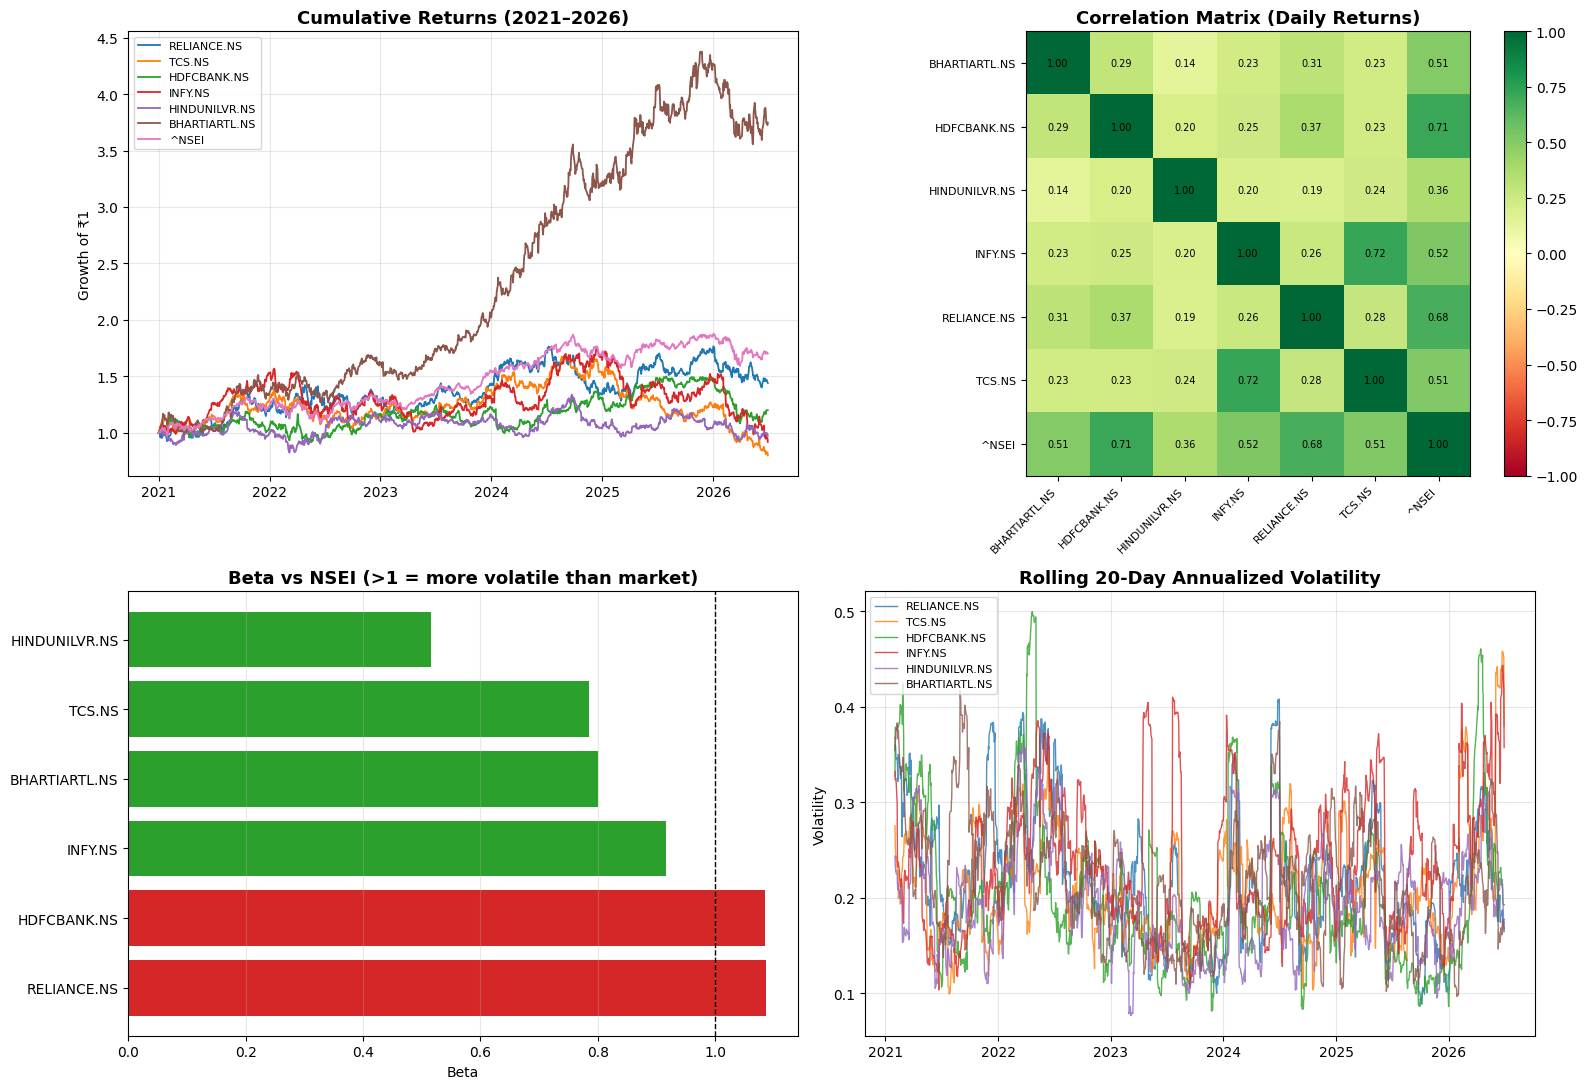

Dashboard saved as dashboard_overview.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. Cumulative returns comparison
ax1 = axes[0, 0]
for ticker in TICKERS:
    df = processed_data[ticker]
    ax1.plot(df["Date"], df["Cumulative_Return"], label=ticker, linewidth=1.3)
ax1.set_title("Cumulative Returns (2021–2026)", fontsize=13, fontweight="bold")
ax1.set_ylabel("Growth of ₹1")
ax1.legend(fontsize=8, loc="upper left")
ax1.grid(alpha=0.3)

# 2. Correlation heatmap
ax2 = axes[0, 1]
im = ax2.imshow(corr_matrix, cmap="RdYlGn", vmin=-1, vmax=1)
ax2.set_xticks(range(len(corr_matrix.columns)))
ax2.set_yticks(range(len(corr_matrix.columns)))
ax2.set_xticklabels(corr_matrix.columns, rotation=45, ha="right", fontsize=8)
ax2.set_yticklabels(corr_matrix.columns, fontsize=8)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax2.text(j, i, f"{corr_matrix.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7)
ax2.set_title("Correlation Matrix (Daily Returns)", fontsize=13, fontweight="bold")
plt.colorbar(im, ax=ax2, fraction=0.046)

# 3. Beta comparison bar chart
ax3 = axes[1, 0]
colors = ["#d62728" if b > 1 else "#2ca02c" for b in beta_df["Beta"]]
ax3.barh(beta_df["Ticker"], beta_df["Beta"], color=colors)
ax3.axvline(x=1, color="black", linestyle="--", linewidth=1)
ax3.set_title("Beta vs NSEI (>1 = more volatile than market)", fontsize=13, fontweight="bold")
ax3.set_xlabel("Beta")
ax3.grid(alpha=0.3, axis="x")

# 4. Rolling 20d volatility over time
ax4 = axes[1, 1]
for ticker in TICKERS:
    if ticker == "^NSEI":
        continue
    df = processed_data[ticker]
    ax4.plot(df["Date"], df["Volatility_20d"], label=ticker, linewidth=1, alpha=0.8)
ax4.set_title("Rolling 20-Day Annualized Volatility", fontsize=13, fontweight="bold")
ax4.set_ylabel("Volatility")
ax4.legend(fontsize=8, loc="upper left")
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("dashboard_overview.png", dpi=150, bbox_inches="tight")
plt.show()

print("Dashboard saved as dashboard_overview.png")

In [13]:
report_lines = []
report_lines.append("="*60)
report_lines.append("QUANTITATIVE MARKET ANALYSIS — SUMMARY REPORT")
report_lines.append(f"Period: {combined_df['Date'].min().date()} to {combined_df['Date'].max().date()}")
report_lines.append("="*60)

# Best/worst performer by cumulative return
final_returns = {t: processed_data[t]["Cumulative_Return"].iloc[-1] for t in TICKERS}
best = max(final_returns, key=final_returns.get)
worst = min(final_returns, key=final_returns.get)

report_lines.append(f"\n1. PERFORMANCE")
report_lines.append(f"   Best performer:  {best} ({(final_returns[best]-1)*100:.1f}% total return)")
report_lines.append(f"   Worst performer: {worst} ({(final_returns[worst]-1)*100:.1f}% total return)")

# Beta insights
report_lines.append(f"\n2. RISK (BETA vs NSEI)")
high_beta = beta_df.iloc[0]
low_beta = beta_df.iloc[-1]
report_lines.append(f"   Most aggressive: {high_beta['Ticker']} (Beta={high_beta['Beta']}, R²={high_beta['R_squared']})")
report_lines.append(f"   Most defensive:  {low_beta['Ticker']} (Beta={low_beta['Beta']}, R²={low_beta['R_squared']})")

# Volatility insights
report_lines.append(f"\n3. DISPERSION (VOLATILITY)")
riskiest = vol_summary.iloc[0]
calmest = vol_summary.iloc[-1]
report_lines.append(f"   Highest volatility: {riskiest['Ticker']} ({riskiest['avg_vol_20d']*100:.1f}% annualized)")
report_lines.append(f"   Lowest volatility:  {calmest['Ticker']} ({calmest['avg_vol_20d']*100:.1f}% annualized)")

# Correlation insights
report_lines.append(f"\n4. DIVERSIFICATION")
corr_no_diag = corr_matrix.where(~np.eye(len(corr_matrix), dtype=bool))
max_pair = corr_no_diag.stack().idxmax()
min_pair = corr_no_diag.stack().idxmin()
report_lines.append(f"   Most correlated pair:  {max_pair[0]} & {max_pair[1]} ({corr_no_diag.loc[max_pair]:.2f})")
report_lines.append(f"   Least correlated pair: {min_pair[0]} & {min_pair[1]} ({corr_no_diag.loc[min_pair]:.2f})")
report_lines.append(f"   -> Least correlated pair offers the best diversification benefit")

report_lines.append("\n" + "="*60)

report_text = "\n".join(report_lines)
print(report_text)

with open("summary_report.txt", "w") as f:
    f.write(report_text)
print("\nSaved as summary_report.txt")

QUANTITATIVE MARKET ANALYSIS — SUMMARY REPORT
Period: 2021-01-01 to 2026-06-30

1. PERFORMANCE
   Best performer:  BHARTIARTL.NS (274.7% total return)
   Worst performer: TCS.NS (-19.9% total return)

2. RISK (BETA vs NSEI)
   Most aggressive: RELIANCE.NS (Beta=1.087, R²=0.459)
   Most defensive:  HINDUNILVR.NS (Beta=0.516, R²=0.13)

3. DISPERSION (VOLATILITY)
   Highest volatility: INFY.NS (23.8% annualized)
   Lowest volatility:  ^NSEI (13.3% annualized)

4. DIVERSIFICATION
   Most correlated pair:  INFY.NS & TCS.NS (0.72)
   Least correlated pair: BHARTIARTL.NS & HINDUNILVR.NS (0.14)
   -> Least correlated pair offers the best diversification benefit


Saved as summary_report.txt
